Let's look at the latest database of Gamma Ray Bursts.

 - The database can be downloaded at https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt
 - You can find the physical meaning of each variable at https://user-web.icecube.wisc.edu/~grbweb_public/Variables.html 


This edition of "get your hands dirty" is very open ended (we're getting closer and closer to real research...). You have a cool dataset, explore it! Play with the data, apply some of the tecniques we have seen in classes so far, etc. **Be creative! You're discovering**


Some relevant physical questions you might want to tackle include:

- Does the distribution contain different sub-populations? How many?
- What's the threshold between the classes?
- If you try two clustering methods, do you get more or less the same?
- How do methods respond to outliers? i.e leave some data out and refit
- What variable(s) shows the multi-modality more evidently?
- Are all GRBs equally likely to be observed? 



In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names= np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])


C:\Users\lm101\AppData\Local\Temp\ipykernel_21704\4041969003.py:11: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')


In [2]:
names

array(['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
       'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
       'redshift', "'T100'", 'GBM_located', 'mjd_(T0)'], dtype='<U14')

**T90** = Duration of the time interval during which 90% of the GRB photon counts are observed, starting at 5% and ending at 95%. This parameter depends on the efficiency with which photons of various energies can be observed, making the T90 dependent on the detector.


**fluence** = The time integrated total energy per unit surface.

In [3]:
T90_idx = np.where(names == 'T90')[0][0] 
T90 = np.array(data[T90_idx], dtype=float)

fluence_idx = np.where(names == 'fluence')[0][0] 
fluence = np.array(data[fluence_idx], dtype=float)
print(T90)

[   1.856   41.725 -999.    ...    3.136  208.576    5.184]


Filter out the missing data (-999) and plot histograms:

In [4]:
T90 = T90[~(T90==-999)]
fluence = fluence[~(fluence==-999)]

In [5]:
T90.shape

(7996,)

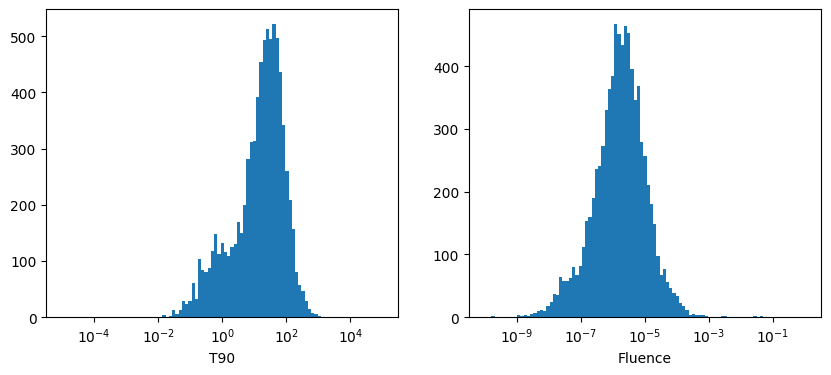

In [6]:
fig,axes = plt.subplots(figsize = (10, 4), ncols = 2)

axes[0].hist(T90, np.logspace(-5, 5, 100))
axes[0].semilogx()
axes[0].set_xlabel('T90')

axes[1].hist(fluence, np.logspace(-10, 0, 100))
axes[1].semilogx()
axes[1].set_xlabel('Fluence')

plt.show()

It's easier to see two different distributions in the T90 data than in the fluence, let's start from there:

In [7]:
from sklearn.cluster import KMeans

In [8]:
kmeans = KMeans(n_clusters = 2)
X = np.log10(T90).reshape(-1, 1)
kmeans.fit(X)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [9]:
y = kmeans.predict(X)

In [10]:
print('Threshold: ', min(max(T90[y==0]), max(T90[y==1])), 
      's\nCluster centres: ', 10**kmeans.cluster_centers_[1][0], ' ', 10**kmeans.cluster_centers_[0][0])

Threshold:  5.44 s
Cluster centres:  33.01951858853736   0.9151691116125676


In [11]:
kmeans_threshold = min(max(T90[y==0]), max(T90[y==1]))

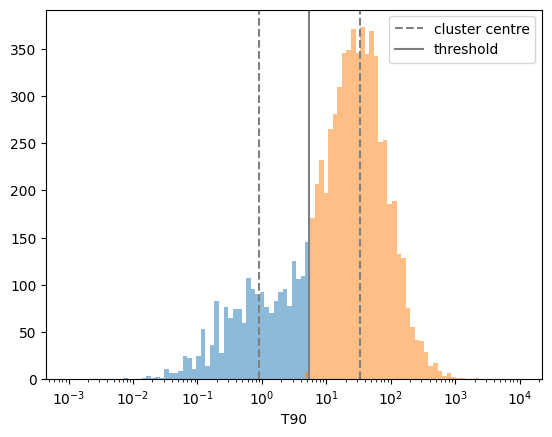

In [12]:
plt.axvline(10**(kmeans.cluster_centers_[0][0]), 0, 2000, color = 'gray', ls='--', label='cluster centre')
plt.axvline(10**(kmeans.cluster_centers_[1][0]), 0, 2000, color = 'gray', ls='--')
plt.axvline(kmeans_threshold, color = 'gray', label = 'threshold')
plt.hist(T90[y == 0], np.logspace(-3, 4, 100), alpha = 0.5)
plt.hist(T90[y == 1], np.logspace(-3, 4, 100), alpha = 0.5)
plt.semilogx()
plt.xlabel('T90')
plt.legend()
plt.show()

Let's now try Mean-shift Clustering! This way we can see if we should really expect two clusters or if we could potentially see more.
    
    class sklearn.cluster.MeanShift(*, bandwidth=None, seeds=None, bin_seeding=False, min_bin_freq=1, cluster_all=True, n_jobs=None, max_iter=300)

In [13]:
from sklearn.cluster import MeanShift

In [14]:
mshift = MeanShift(bandwidth = 0.3, n_jobs = -1)
mshift.fit(X)

,bandwidth,0.3
,seeds,None
,bin_seeding,False
,min_bin_freq,1
,cluster_all,True
,n_jobs,-1
,max_iter,300


In [15]:
y_mshift = mshift.labels_
meanshift_threshold = min(max(T90[y_mshift == 1]), max(T90[y_mshift == 0]))

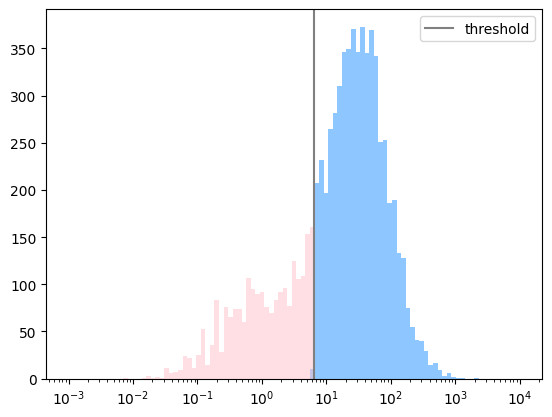

In [16]:
plt.hist(T90[y_mshift == 0], np.logspace(-3, 4, 100), color = 'dodgerblue', alpha = 0.5)
plt.hist(T90[y_mshift == 1], np.logspace(-3, 4, 100), color = 'pink',  alpha = 0.5)
plt.axvline(meanshift_threshold, c='gray', label='threshold')
plt.legend()
plt.semilogx()
plt.show()

In [17]:
print('number of predicted clusters:', len(np.unique(y_mshift)))

number of predicted clusters: 2


In [18]:
print(f'THRESHOLDS\nK-Means: {kmeans_threshold} s\nMean Shift: {meanshift_threshold} s')

THRESHOLDS
K-Means: 5.44 s
Mean Shift: 6.44 s


What if I remove 'outliers'?

In [19]:
bot, top = np.percentile(T90, [10, 90])
T90_new = T90[(T90>bot)&(T90<top)]

X_new = np.log10(T90_new).reshape(-1, 1)

In [20]:
kmeans = KMeans(n_clusters = 2)
kmeans.fit(X_new)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [21]:
y = kmeans.predict(X_new)
max(T90_new[y==1])

np.float64(99.584)

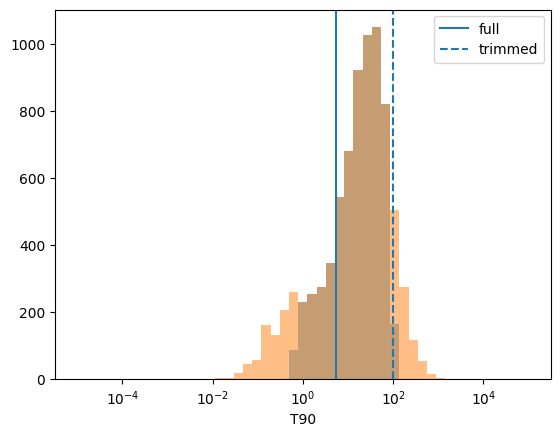

In [22]:
plt.hist(T90_new, np.logspace(-5, 5), alpha = 0.5)
plt.hist(T90, np.logspace(-5, 5), alpha = 0.5)
plt.axvline(kmeans_threshold, label ='full')
plt.axvline(max(T90_new[y==1]), ls = 'dashed', label ='trimmed')
plt.legend()
plt.semilogx()
plt.xlabel('T90')
plt.show()

The threshold tends to move towards the right, depending on how much of the distribution we are trimming away. Can we instead cluster in 2D?

In [23]:
#redefine both arrays to only keep points without missing data
T90_idx = np.where(names == 'T90')[0][0] 
T90 = np.array(data[T90_idx], dtype=float)

fluence_idx = np.where(names == 'fluence')[0][0] 
fluence = np.array(data[fluence_idx], dtype=float)

In [24]:
index = []

for i in range(len(T90)):
    if T90[i] == -999 or fluence[i]== -999 or fluence[i]==0: index.append(i)

T90 = np.delete(T90, index)
fluence = np.delete(fluence, index)

In [25]:
T90.shape, fluence.shape

((7851,), (7851,))

In [26]:
X = np.array([np.log10(T90), np.log10(fluence)]).T

Text(0, 0.5, 'fluence')

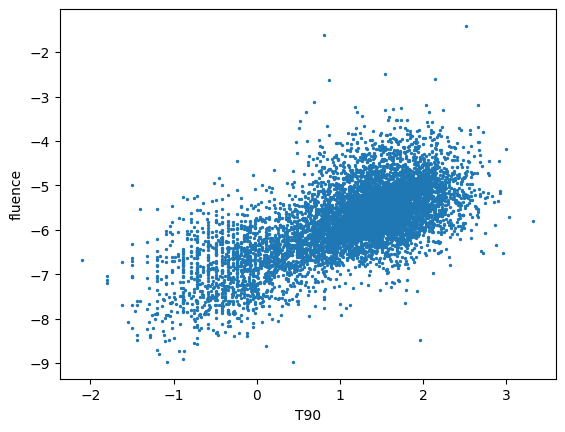

In [27]:
plt.scatter(X[:, 0], X[:, 1], s = 2)
plt.xlabel('T90')
plt.ylabel('fluence')

In [28]:
kmeans = KMeans(n_clusters = 2)
kmeans.fit(X)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [29]:
y = kmeans.labels_

In [30]:
import seaborn as sns

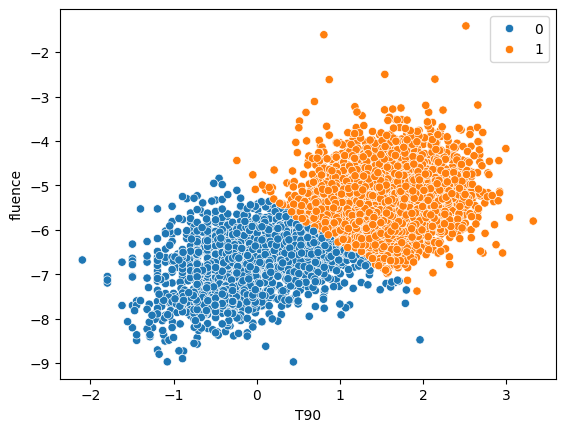

In [31]:
sns.scatterplot(x = X[:, 0], y = X[:, 1], hue = y)
plt.xlabel('T90')
plt.ylabel('fluence')
plt.show()

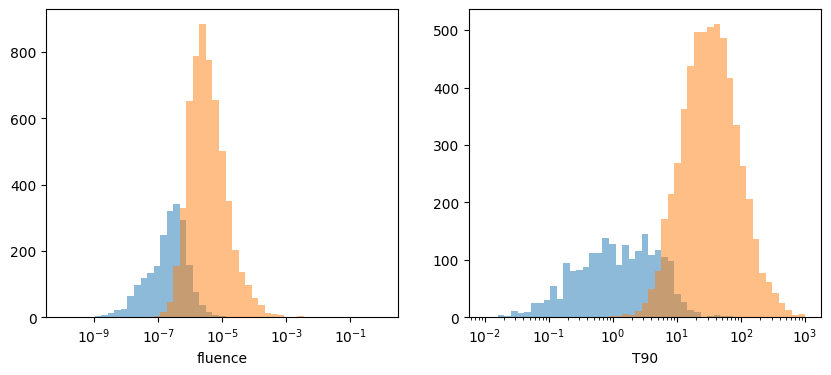

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(fluence[y == 0], np.logspace(-10, 0, 50), alpha=0.5)
ax[0].hist(fluence[y == 1],  np.logspace(-10, 0, 50), alpha=0.5)
ax[0].semilogx()
ax[0].set_xlabel('fluence')

ax[1].hist(T90[y == 0], np.logspace(-2, 3, 50), alpha=0.5)
ax[1].hist(T90[y == 1],  np.logspace(-2, 3, 50), alpha=0.5)
ax[1].semilogx()
ax[1].set_xlabel('T90')

plt.show()

Looks pretty good! Any selection effects? If we were equally likely to observe an event from the two populations, we would see roughly the same number of them. But we don't. Maybe different distributions in redshift could explains why we see more long GBRs than short.

In [33]:
z_idx = np.where(names == 'redshift')[0][0] 
z = np.array(data[z_idx], dtype=float)
z = np.delete(z, index)

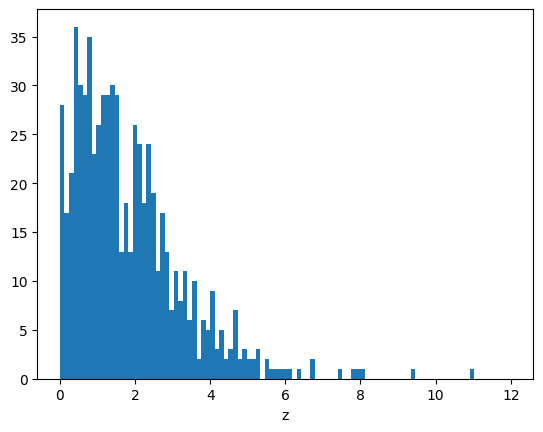

In [34]:
plt.hist(z, bins = np.linspace(0, 12, 100))
plt.xlabel('z')
plt.show()

In [35]:
#redefine both arrays to only keep points without missing data
T90_idx = np.where(names == 'T90')[0][0] 
T90 = np.array(data[T90_idx], dtype=float)

fluence_idx = np.where(names == 'fluence')[0][0] 
fluence = np.array(data[fluence_idx], dtype=float)

z_idx = np.where(names == 'redshift')[0][0] 
z = np.array(data[z_idx], dtype=float)

In [36]:
index = []

for i in range(len(T90)):
    if T90[i] == -999 or fluence[i]== -999 or fluence[i]==0 or z[i]==-999: index.append(i)

T90 = np.delete(T90, index)
fluence = np.delete(fluence, index)
z=np.delete(z, index)

X = np.array([np.log10(T90), np.log10(fluence)]).T

In [37]:
kmeans = KMeans(n_clusters = 2)
kmeans.fit(X)
y = kmeans.labels_

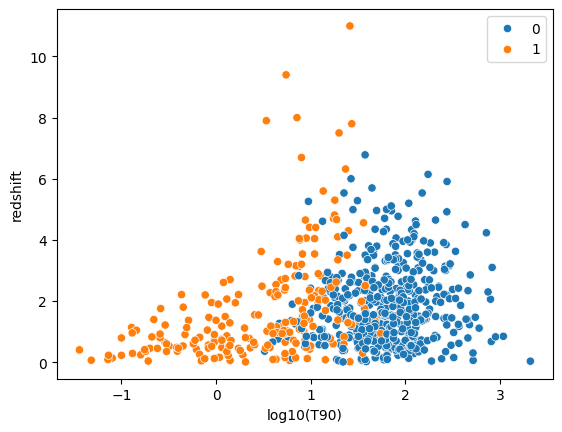

In [41]:
ax = sns.scatterplot(x = X[:, 0], y = z, hue = y)

plt.xlabel('log10(T90)')
plt.ylabel('redshift')
plt.show()

In [42]:
print(len(z[y==0]), ':', len(z))

467 : 681


So something to take into account:
- we have a redshift measurement only for a small subset of the overall dataset,
- and many more redshift measurements for long GRBs compared to short ones,
- taking the previous plot at face value, both populations are present at all redshifts,
- so the underlying cause might be just related to short GRBs being harder to observe, both due to their signal being shorter in time and with less integrated energy (fluence)